1. Imports and data 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

prices = pd.read_csv(
    "data/processed/clean_prices.csv",
    index_col=0,
    parse_dates=True
).dropna()

strategy = pd.read_csv(
    "data/processed/strategy_signals.csv",
    index_col=0,
    parse_dates=True
).dropna()

prices.head()

,KO,PEP
Date,,
2018-01-02,34.816475,89.690910
2018-01-03,34.740017,89.455414
2018-01-04,35.229328,89.896042
2018-01-05,35.221661,90.154335
2018-01-08,35.168156,89.637733


2. Calculate daily returns 

In [2]:
returns = prices.pct_change().fillna(0)

returns.head()

,KO,PEP
Date,,
2018-01-02,0.000000,0.000000
2018-01-03,-0.002196,-0.002626
2018-01-04,0.014085,0.004926
2018-01-05,-0.000218,0.002873
2018-01-08,-0.001519,-0.005730


3. Build the pairs trading return 

Position meaning : 
+1 = Long KO / Short PEP
-1 = Short KO / Long PEP
 0 = No position

In [ ]:
beta = strategy["spread"].cov(
    np.log(prices["PEP"])
) / np.log(prices["PEP"]).var()

print(f"Beta: {beta:.4f}")

Beta: -0.0087


In [ ]:
# reuse the beta from the previous step 

import statsmodels.api as sm

log_prices = np.log(prices)

X = sm.add_constant(log_prices["PEP"])
model = sm.OLS(log_prices["KO"], X).fit()

beta = model.params["PEP"]

print(f"Hedge ratio β = {beta:.4f}")

Hedge ratio β = 0.9366


4. Calculate spread returns 

R_long = R_KO - bR_PEP
R_short = -(R_KO - bR_PEP)

In [5]:
spread_returns = (
    returns["KO"] -
    beta * returns["PEP"]
)

In [6]:
# apply our positions 

position = strategy["position"]

strategy_returns = (
    position.shift(1) *
    spread_returns
).fillna(0)

Why shift(1)? 

Suppose today's Z-score reaches +2.5. We discover that after today's close. We cannot magically execute before today's price movement happened.

Thus: 
Today's signal
      ↓
Tomorrow's position
      ↓
Tomorrow's return
 
\\ important form of look-ahead-bias prevention.

5. Build the equity curve 

In [7]:
equity_curve = (1 + strategy_returns).cumprod()

equity_curve.head()

Date
2018-01-02    1.0
2018-01-03    1.0
2018-01-04    1.0
2018-01-05    1.0
2018-01-08    1.0
dtype: float64

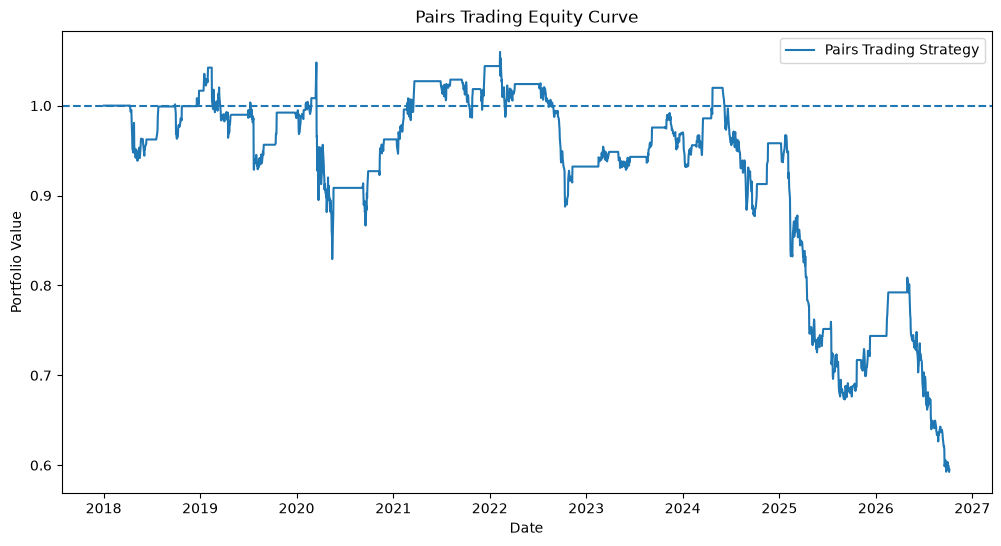

In [8]:
# plot it 

plt.figure(figsize=(12, 6))

plt.plot(
    equity_curve,
    label="Pairs Trading Strategy"
)

plt.axhline(
    1,
    linestyle="--"
)

plt.title("Pairs Trading Equity Curve")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.legend()
plt.show()

6. Calculate total return 

In [9]:
total_return = equity_curve.iloc[-1] - 1

print(f"Total return: {total_return:.2%}")

Total return: -40.49%


7. Calculate annualized return 

In [10]:
days = len(strategy_returns)

annualized_return = (
    (1 + total_return) ** (252 / days)
    - 1
)

print(f"Annualized return: {annualized_return:.2%}")

Annualized return: -5.77%


8. Calculate volatility 

In [11]:
annualized_volatility = (
    strategy_returns.std() *
    np.sqrt(252)
)

print(
    f"Annualized volatility: "
    f"{annualized_volatility:.2%}"
)

Annualized volatility: 11.66%


9. Sharpe Ratio 

In [12]:
sharpe_ratio = (
    strategy_returns.mean() /
    strategy_returns.std()
) * np.sqrt(252)

print(f"Sharpe ratio: {sharpe_ratio:.2f}")

Sharpe ratio: -0.45


As a rough interpretation : 
< 0       Poor
0–1       Weak/modest
1–2       Interesting
2+        Strong

10. Maximum drawdown 

In [13]:
running_max = equity_curve.cummax()

drawdown = (
    equity_curve / running_max
) - 1

max_drawdown = drawdown.min()

print(
    f"Maximum drawdown: "
    f"{max_drawdown:.2%}"
)

Maximum drawdown: -44.09%


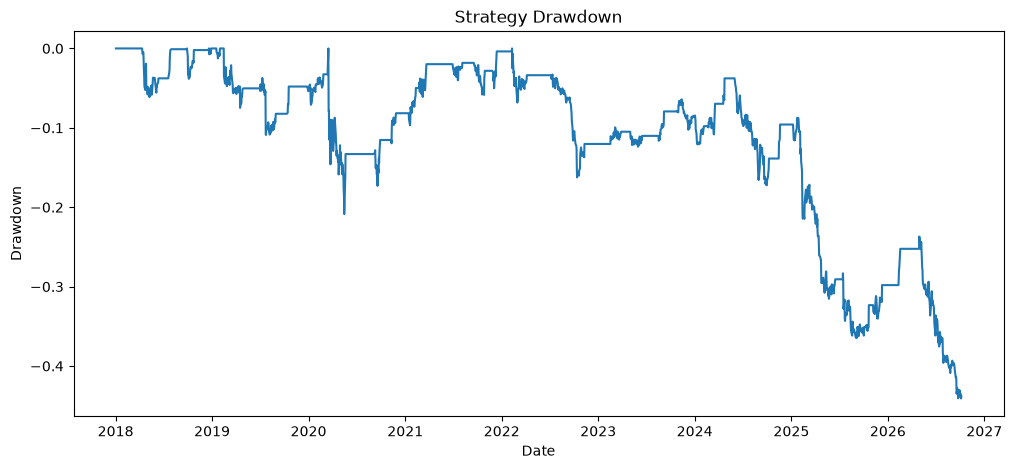

In [14]:
# plot it 

plt.figure(figsize=(12, 5))

plt.plot(drawdown)

plt.title("Strategy Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.show()

11. Win rate 

In [15]:
winning_days = (strategy_returns > 0).sum()
trading_days = (strategy_returns != 0).sum()

win_rate = winning_days / trading_days

print(f"Winning trading days: {winning_days}")
print(f"Trading days: {trading_days}")
print(f"Win rate: {win_rate:.2%}")

Winning trading days: 523
Trading days: 1100
Win rate: 47.55%


12. Research summary 

In [16]:
print("=" * 40)
print("PAIRS TRADING BACKTEST")
print("=" * 40)

print(f"Total return:          {total_return:.2%}")
print(f"Annualized return:     {annualized_return:.2%}")
print(f"Annualized volatility: {annualized_volatility:.2%}")
print(f"Sharpe ratio:          {sharpe_ratio:.2f}")
print(f"Maximum drawdown:      {max_drawdown:.2%}")
print(f"Win rate:              {win_rate:.2%}")
print("=" * 40)

PAIRS TRADING BACKTEST
Total return:          -40.49%
Annualized return:     -5.77%
Annualized volatility: 11.66%
Sharpe ratio:          -0.45
Maximum drawdown:      -44.09%
Win rate:              47.55%


So far, we built... 

Market Data
     ↓
EDA
     ↓
Cointegration
     ↓
Hedge Ratio
     ↓
Spread
     ↓
Z-score
     ↓
Trading Signals
     ↓
<BACKTEST> 
     ↓
Returns
     ↓
Sharpe
     ↓
Drawdown

Next, we will take transaction costs + slippage + proper trade-level analysis into account. 

*A strategy that looks profitable (although it is less so in this case) before costs can easily become unprofitable after realistic execution costs. 